In [1]:
#step 1: import library yang diperlukan
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

housing = pd.read_csv("housing.csv")

# buat kategori berdasarkan median_income agar tes set sesuai dengan proporsi ditribusi median_income
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5],
)

# buat data train dan test dengan stratified sampling berdasarkan income_cat
train_set, test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42
)

# cek hasil proporsi income_cat di test set dan train set
test_set["income_cat"].value_counts() / len(test_set)
train_set["income_cat"].value_counts() / len(train_set)


# hapus kolom income_cat karena sudah tidak diperlukan lagi
for set_ in (train_set, test_set):
    set_.drop("income_cat", axis=1, inplace=True)

housing=train_set.copy()
housing_train_x= train_set.drop("median_house_value", axis=1)
housing_labels_train_y = train_set["median_house_value"].copy()

In [2]:
#buat class untuk data preparation untuk model clustering
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted, check_array
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel


class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self #always return self in fit method
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    def get_feature_names_out(self, names=None):
        return [f"cluster_similarity_{i}" for i in range(self.n_clusters)]

In [3]:
#buat pipeline untuk data preparation
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]
def ratio_names(function_transformer, feature_names_in):
    return ["ratio"]
def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_names),
        StandardScaler(),
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)
    
cluster_simil= ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)

default_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)   

preprocessing = ColumnTransformer([
    ("bedrooms_per_room", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_household", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_household", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "households", 
                           "population", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
],
    remainder=default_pipeline)





In [5]:
housing_prepared = preprocessing.fit_transform(housing_train_x)
housing_prepared.shape

(16512, 24)

In [6]:
preprocessing.get_feature_names_out()

array(['bedrooms_per_room__ratio', 'rooms_per_household__ratio',
       'people_per_household__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__households', 'log__population',
       'log__median_income', 'geo__cluster_similarity_0',
       'geo__cluster_similarity_1', 'geo__cluster_similarity_2',
       'geo__cluster_similarity_3', 'geo__cluster_similarity_4',
       'geo__cluster_similarity_5', 'geo__cluster_similarity_6',
       'geo__cluster_similarity_7', 'geo__cluster_similarity_8',
       'geo__cluster_similarity_9', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

In [12]:
#melihat hasil preprocessing dengan visualisasi histogram
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cek dulu nama-nama kolom yang keluar dari pipeline
column_names = preprocessing.get_feature_names_out()

# 2. Convert hasil preprocessing ke DataFrame biar ada nama kolomnya
housing_prepared_df = pd.DataFrame(housing_prepared, columns=column_names)

housing_prepared_df.head()

,bedrooms_per_room__ratio,rooms_per_household__ratio,people_per_household__ratio,log__total_bedrooms,log__total_rooms,log__households,log__population,log__median_income,geo__cluster_similarity_0,geo__cluster_similarity_1,...,geo__cluster_similarity_6,geo__cluster_similarity_7,geo__cluster_similarity_8,geo__cluster_similarity_9,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age
0,1.846624,-0.866027,-0.330204,1.324114,0.637892,1.310369,0.456906,-1.071522,4.581829e-01,1.241847e-14,...,8.489216e-04,9.770322e-01,2.382191e-08,3.819126e-18,0.0,0.0,0.0,1.0,0.0,1.861119
1,-0.508121,0.024550,-0.253616,-0.252671,-0.063576,-0.142030,-0.711654,1.194712,6.511495e-10,9.579596e-01,...,5.614049e-27,1.260964e-13,1.103491e-01,3.547610e-01,1.0,0.0,0.0,0.0,0.0,0.907630
2,-0.202155,-0.041193,-0.051041,-0.925266,-0.859927,-0.913030,-0.941997,-0.756981,3.432506e-01,4.261141e-15,...,5.641131e-03,7.303265e-01,2.508224e-08,2.669659e-18,0.0,1.0,0.0,0.0,0.0,0.351428
3,-0.149006,-0.034858,-0.141475,0.952773,0.943475,0.925373,0.670700,-0.912253,2.244844e-15,2.704823e-01,...,5.913326e-35,5.201263e-20,1.712982e-03,8.874598e-01,0.0,1.0,0.0,0.0,0.0,-0.919891
4,0.963208,-0.666554,-0.306148,1.437622,1.003590,1.481464,0.719093,0.034537,1.090228e-11,9.422206e-01,...,5.421817e-30,1.048030e-15,2.568824e-02,5.279506e-01,0.0,0.0,0.0,0.0,1.0,0.589800


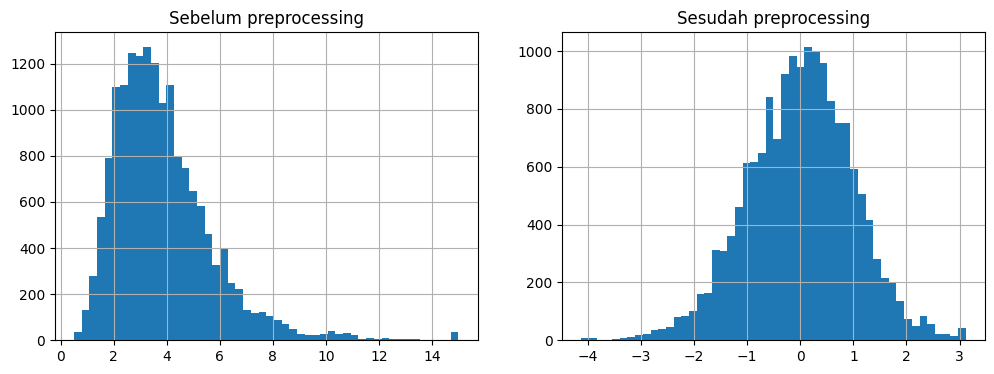

In [6]:
# 3. Pilih SATU fitur asli untuk dibandingkan sebelum vs sesudah
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

housing['median_income'].hist(bins=50, ax=axes[0])
axes[0].set_title('Sebelum preprocessing')

housing_prepared_df['log__median_income'].hist(bins=50, ax=axes[1])
axes[1].set_title('Sesudah preprocessing')

plt.show()

In [ ]:
#select and train a model pertama kita coba linear regression dulu
from sklearn.linear_model import LinearRegression
model_lin_reg = make_pipeline(preprocessing, LinearRegression())
model_lin_reg.fit(housing_train_x, housing_labels_train_y)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms_per_room',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_na...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7aa845053200>)])),
                ('linearregression', LinearRegression())])

In [ ]:
#hasil prediksi dengan linear regression
housing_predictions_lin = model_lin_reg.predict(housing_train_x)
print(housing_predictions_lin[:5].round(-2))
print(housing_labels_train_y[:5].values)
#rmse
from sklearn.metrics import root_mean_squared_error
lin_rmse = root_mean_squared_error(housing_labels_train_y, housing_predictions_lin)
print(f"Linear Regression RMSE sebesar: {lin_rmse}")

[246000. 372700. 135700.  91400. 330900.]
[458300. 483800. 101700.  96100. 361800.]
Linear Regression RMSE sebesar: 68972.88910758484


In [ ]:
#cross validation untuk linear regression
from sklearn.model_selection import cross_val_score
lin_rmses = -cross_val_score(model_lin_reg, housing_train_x, housing_labels_train_y,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

,0
count,10.000000
mean,70003.404818
std,4182.188328
min,65504.765753
25%,68172.065831
50%,68743.995249
75%,70344.943988
max,81037.863741


In [ ]:
#model kedua kita coba decision tree regressor
from sklearn.tree import DecisionTreeRegressor
model_tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
model_tree_reg.fit(housing_train_x, housing_labels_train_y)



Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms_per_room',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_na...
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7aa845053200>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [ ]:
#buat prediksi dengan decision tree regressor
housing_predictions_tree = model_tree_reg.predict(housing_train_x)
#hitung rmse untuk decision tree regressor
from sklearn.metrics import root_mean_squared_error
tree_rmse = root_mean_squared_error(housing_labels_train_y, housing_predictions_tree)
print(housing_predictions_tree[:5].round(-2))
print(housing_labels_train_y[:5].values)
print(f"Tree RMSE sebesar: {tree_rmse}")

[458300. 483800. 101700.  96100. 361800.]
[458300. 483800. 101700.  96100. 361800.]
Tree RMSE sebesar: 0.0


In [ ]:
#mencoba cross validation untuk decision tree regressor
from sklearn.model_selection import cross_val_score
tree_rmses = -cross_val_score(model_tree_reg, housing_train_x, housing_labels_train_y,
                              scoring="neg_root_mean_squared_error", cv=10)


In [ ]:
#hasil cross validation untuk decision tree regressor
hasil_cross_val_tree = print(f"Tree regressor model RMSE Cross Validation: {pd.Series(tree_rmses).describe()}")

Tree regressor model RMSE Cross Validation: count       10.000000
mean     66595.602503
std       1337.872697
min      63842.738493
25%      65867.755437
50%      66902.313238
75%      67634.208944
max      67949.415760
dtype: float64


In [ ]:
#model ketiga kita coba random forest regressor (ensemble dari beberapa decision tree regressor)
from sklearn.ensemble import RandomForestRegressor
model_forest_reg = make_pipeline(preprocessing, RandomForestRegressor(n_estimators=100, random_state=42))
model_forest_reg.fit(housing_train_x, housing_labels_train_y)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms_per_room',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_na...
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ed28d0a6ed0>)])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
#hitung rmse untuk random forest regressor
from sklearn.metrics import root_mean_squared_error
model_forest_reg_predict = model_forest_reg.predict(housing_train_x)
model_forest_reg_predict_rmse = root_mean_squared_error(housing_labels_train_y, model_forest_reg_predict)
print(f"Random Forest RMSE sebesar: {model_forest_reg_predict_rmse}")
print(model_forest_reg_predict[:5].round(-2))
print(housing_labels_train_y[:5].values)

Random Forest RMSE sebesar: 17514.04440992394
[434500. 471600. 110600. 103600. 361400.]
[458300. 483800. 101700.  96100. 361800.]


In [ ]:
#cross validation untuk random forest regressor
from sklearn.model_selection import cross_val_score
forest_rmses = -cross_val_score(model_forest_reg, housing_train_x, housing_labels_train_y,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(forest_rmses).describe()

,0
count,10.000000
mean,47066.454153
std,997.732660
min,45550.961776
25%,46600.978218
50%,47074.477151
75%,47481.029472
max,49144.479548


In [ ]:
#membuat gridsearch untuk hyperparameter tuning random forest regressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42))
])

param_grid = [
    {"preprocessing__geo__n_clusters": [20,25,30],
     "random_forest__max_features": [2, 4, 6, 8]
     },
    
]
grid_search = GridSearchCV(full_pipeline, 
                           param_grid, 
                           cv=3,
                           scoring="neg_root_mean_squared_error",
                           refit=True)
grid_search.fit(housing_train_x, housing_labels_train_y)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms_per_room',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_nam...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7c5f6d61b440>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [20, 25, 30],
                          'random_forest__max_features': [2, 4, 6, 8]}],
             scoring='neg_root_mean_squared_error')

In [ ]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best RMSE: {-grid_search.best_score_}")


Best parameters: {'preprocessing__geo__n_clusters': 25, 'random_forest__max_features': 6}
Best RMSE: 42551.94907117523


In [ ]:
#hasil result dari grid search
grid_cv_rest=pd.DataFrame(grid_search.cv_results_)
grid_cv_rest.sort_values(by="mean_test_score", ascending=False, inplace=True)
grid_cv_rest[["param_preprocessing__geo__n_clusters", 
              "param_random_forest__max_features", 
              "mean_test_score", 
              "std_test_score", 
              "rank_test_score"]]

,param_preprocessing__geo__n_clusters,param_random_forest__max_features,mean_test_score,std_test_score,rank_test_score
6,25,6,-42551.949071,659.526140,1
10,30,6,-42579.583039,679.383600,2
11,30,8,-42619.658413,553.864128,3
9,30,4,-42803.205116,621.113718,4
7,25,8,-42860.852611,547.236269,5
5,25,4,-42882.690576,588.481047,6
2,20,6,-42942.718361,605.247452,7
1,20,4,-43026.192498,591.024623,8
3,20,8,-43286.070559,605.512176,9
0,20,2,-44229.122843,695.788873,10


In [ ]:
full_pipeline.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__transform_input', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 

In [14]:
# buat randomsearch untuk hyperparameter tuning random forest regressor
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

full_pipeline = Pipeline(
    [
        ("preprocessing", preprocessing),
        ("random_forest", RandomForestRegressor(random_state=42)),
    ]
)

param_distribs = {
    "preprocessing__geo__n_clusters": randint(low=3, high=50),
    "random_forest__max_features": randint(low=2, high=25),
}

rnd_search_forest_reg = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_distribs,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    refit=True,
)
rnd_search_forest_reg.fit(housing_train_x, housing_labels_train_y)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms_per_room',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(featu...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e27f135e510>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e27f135d370>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [8]:
dir(rnd_search_forest_reg.best_estimator_.named_steps["random_forest"])

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_compute_oob_predictions',
 '_compute_partial_dependence_recursion',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_estimators_indices',
 '_get_metadata_request',
 '_get_oob_predictions',
 '_get_param_names',
 '_get_tags',
 '_make_estimator',
 '_more_tags',
 '_n_samples

In [15]:
print(f"Best parameters: {rnd_search_forest_reg.best_params_}")
print(f"Best RMSE: {-rnd_search_forest_reg.best_score_}")

Best parameters: {'preprocessing__geo__n_clusters': 45, 'random_forest__max_features': 9}
Best RMSE: 42204.5366613429


In [16]:
#hasil result dari random search
rnd_cv_rest=pd.DataFrame(rnd_search_forest_reg.cv_results_)
rnd_cv_rest.sort_values(by="mean_test_score", ascending=False, inplace=True)
rnd_cv_rest[["param_preprocessing__geo__n_clusters", 
              "param_random_forest__max_features",
              "mean_test_score", 
              "std_test_score", 
              "rank_test_score"]]

,param_preprocessing__geo__n_clusters,param_random_forest__max_features,mean_test_score,std_test_score,rank_test_score
2,45,9,-42204.536661,643.986324,1
7,38,9,-42462.078232,677.093901,2
8,26,4,-42850.478881,650.943017,3
3,23,8,-43115.660799,497.943169,4
0,41,21,-43440.512181,392.711158,5
1,31,16,-43700.527780,442.451074,6
6,26,22,-44941.647844,442.920483,7
5,13,12,-45283.207094,535.888552,8
9,24,22,-45289.976360,412.212973,9
4,21,24,-45726.410111,332.386764,10


In [17]:
rnd_cv_rest.to_csv("rnd_cv_rest.csv", index=False)

In [11]:
#Analisa Model Terbaik dan lihat kesalahannya
final_model = rnd_search_forest_reg.best_estimator_
feature_importances = final_model.named_steps["random_forest"].feature_importances_
feature_importances.round(2)

array([0.06, 0.06, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.01, 0.01,
       0.02, 0.01, 0.  , 0.01, 0.01, 0.01, 0.02, 0.01, 0.  , 0.01, 0.01,
       0.01, 0.01, 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01,
       0.02, 0.01, 0.01, 0.01, 0.01, 0.04, 0.01, 0.02, 0.01, 0.02, 0.02,
       0.02, 0.02, 0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

In [12]:
#buat tabel agar mudah dibaca
sorted(zip(feature_importances, 
           final_model.named_steps["preprocessing"].get_feature_names_out()), 
       reverse=True)

[(np.float64(0.18591696319983275), 'log__median_income'),
 (np.float64(0.07577700824048143), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.06207283003269523), 'bedrooms_per_room__ratio'),
 (np.float64(0.05675789635498957), 'rooms_per_household__ratio'),
 (np.float64(0.049117732372007554), 'people_per_household__ratio'),
 (np.float64(0.04469448490020586), 'geo__cluster_similarity_30'),
 (np.float64(0.02208265139777225), 'geo__cluster_similarity_25'),
 (np.float64(0.021423997548954028), 'geo__cluster_similarity_9'),
 (np.float64(0.02057444826644745), 'geo__cluster_similarity_36'),
 (np.float64(0.0197473957686161), 'geo__cluster_similarity_37'),
 (np.float64(0.018825845767067178), 'geo__cluster_similarity_34'),
 (np.float64(0.016283538080952998), 'geo__cluster_similarity_18'),
 (np.float64(0.01570943574476515), 'geo__cluster_similarity_3'),
 (np.float64(0.015420076821359872), 'geo__cluster_similarity_35'),
 (np.float64(0.015369728077455364), 'geo__cluster_similarity_32'),
 (np.float64(0.

In [13]:
model_final_predictions = final_model.predict(housing_train_x)
print(model_final_predictions[:5].round(-2))
print(housing_labels_train_y[:5].values)

[445900. 452700. 107600. 100800. 334000.]
[458300. 483800. 101700.  96100. 361800.]


In [11]:
#contoh kalo pakai selectfrom model_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("select", SelectFromModel(
        RandomForestRegressor(random_state=42),
        threshold="median"
    )),
    ("random_forest", RandomForestRegressor(random_state=42))
])

param_distribs = {
    "preprocessing__geo__n_clusters": randint(low=3, high=50),
    "random_forest__max_features": randint(low=2, high=25),
}

rnd_search_forest_reg = RandomizedSearchCV(
    pipeline,  # bukan full_pipeline
    param_distributions=param_distribs,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    refit=True,
)
rnd_search_forest_reg.fit(housing_train_x, housing_labels_train_y)


: 

: 

In [14]:
#analisa kesalahan prediksi model terbaik dan model fairness
comparison = pd.DataFrame({
    "actual": housing_labels_train_y.values,
    "predicted": model_final_predictions
})

comparison["error"] = (
    comparison["predicted"]
    - comparison["actual"]
)

comparison.head(3).round(-2)
   

,actual,predicted,error
0,458300.0,445900.0,-12400.0
1,483800.0,452700.0,-31100.0
2,101700.0,107600.0,5900.0


In [15]:
comparison["abs_error"] = abs(
    comparison["error"]
)

comparison.sort_values(
    "abs_error",
    ascending=False
).head(5)

,actual,predicted,error,abs_error
9125,500001.0,358848.51,-141152.49,141152.49
1238,475000.0,336858.00,-138142.00,138142.00
468,500001.0,367694.63,-132306.37,132306.37
2746,500001.0,375581.65,-124419.35,124419.35
1765,500000.0,376846.00,-123154.00,123154.00


In [16]:
#Data error terbesar
housing.iloc[9125]

,19184
longitude,-121.76
latitude,37.26
housing_median_age,17.0
total_rooms,250.0
total_bedrooms,52.0
population,141.0
households,51.0
median_income,4.6458
median_house_value,500001.0
ocean_proximity,<1H OCEAN


In [29]:
housing_train_x['median_income'].describe()

,median_income
count,16512.000000
mean,3.870428
std,1.891936
min,0.499900
25%,2.562500
50%,3.538500
75%,4.750000
max,15.000100


In [18]:
#kelompokkan data menjadi 2 kelompok berdasarkan median_income, yaitu kelompok kaya dan miskin
rich = housing_train_x[
    housing_train_x["median_income"] >= 3.538500
]

poor = housing_train_x[
    housing_train_x["median_income"] < 3.538500
]
#target
y_rich = housing_labels_train_y.loc[rich.index]
y_poor = housing_labels_train_y.loc[poor.index]

#prediksi
pred_rich = final_model.predict(rich)
pred_poor = final_model.predict(poor)

#hitung rmse untuk masing-masing kelompok
from sklearn.metrics import root_mean_squared_error

rmse_rich = root_mean_squared_error(
    y_rich,
    pred_rich
)

rmse_poor = root_mean_squared_error(
    y_poor,
    pred_poor
)

print(f"RMSE Kelompok Kaya: {rmse_rich:.0f}")
print(f"RMSE Kelompok Miskin: {rmse_poor:.0f}")


RMSE Kelompok Kaya: 15994
RMSE Kelompok Miskin: 14441


In [30]:
#kelompok berdasarkan population
housing_train_x['population'].describe()

,population
count,16512.000000
mean,1425.513929
std,1094.795467
min,3.000000
25%,787.000000
50%,1167.000000
75%,1726.000000
max,16305.000000


In [19]:
urban = housing_train_x[
    housing_train_x["population"] > 1167
]

rural = housing_train_x[
    housing_train_x["population"] <= 1167
]

#target
y_urban = housing_labels_train_y.loc[urban.index]
y_rural = housing_labels_train_y.loc[rural.index]

#prediksi
pred_urban = final_model.predict(urban)
pred_rural = final_model.predict(rural)

#hitung rmse untuk masing-masing kelompok
from sklearn.metrics import root_mean_squared_error

rmse_urban = root_mean_squared_error(
    y_urban,
    pred_urban
)

rmse_rural = root_mean_squared_error(
    y_rural,
    pred_rural
)

print(f"RMSE Kelompok Urban: {rmse_urban:.0f}")
print(f"RMSE Kelompok Rural: {rmse_rural:.0f}")


RMSE Kelompok Urban: 13744
RMSE Kelompok Rural: 16595


In [34]:
#kelompok berdasarkan OCEAN PROXIMITY
housing_train_x[["ocean_proximity"]].value_counts()

,count
ocean_proximity,
<1H OCEAN,7274
INLAND,5301
NEAR OCEAN,2089
NEAR BAY,1846
ISLAND,2


In [20]:
near_ocean = housing_train_x[
    housing_train_x["ocean_proximity"] == "NEAR OCEAN"
]

island = housing_train_x[
    housing_train_x["ocean_proximity"] == "ISLAND"
]
inland = housing_train_x[
    housing_train_x["ocean_proximity"] == "INLAND"
]
near_bay = housing_train_x[
    housing_train_x["ocean_proximity"] == "NEAR BAY"
]
far_ocean = housing_train_x[
    housing_train_x["ocean_proximity"] == "<1H OCEAN"
]

#target
y_near_ocean = housing_labels_train_y.loc[near_ocean.index]
y_island = housing_labels_train_y.loc[island.index]
y_inland = housing_labels_train_y.loc[inland.index]
y_near_bay = housing_labels_train_y.loc[near_bay.index]
y_far_ocean = housing_labels_train_y.loc[far_ocean.index]

#prediksi
pred_near_ocean = final_model.predict(near_ocean)
pred_island = final_model.predict(island)
pred_inland = final_model.predict(inland)
pred_near_bay = final_model.predict(near_bay)
pred_far_ocean = final_model.predict(far_ocean)

#hitung rmse untuk masing-masing kelompok
from sklearn.metrics import root_mean_squared_error

rmse_near_ocean = root_mean_squared_error(
    y_near_ocean,
    pred_near_ocean
)

rmse_island = root_mean_squared_error(
    y_island,
    pred_island
)

rmse_inland = root_mean_squared_error(
    y_inland,
    pred_inland
)

rmse_near_bay = root_mean_squared_error(
    y_near_bay,
    pred_near_bay
)

rmse_far_ocean = root_mean_squared_error(
    y_far_ocean,
    pred_far_ocean
)



print(f"RMSE Kelompok Near Ocean: {rmse_near_ocean:.0f}")
print(f"RMSE Kelompok Island: {rmse_island:.0f}")
print(f"RMSE Kelompok Inland: {rmse_inland:.0f}")
print(f"RMSE Kelompok Near Bay: {rmse_near_bay:.0f}")
print(f"RMSE Kelompok Far Ocean: {rmse_far_ocean:.0f}")

RMSE Kelompok Near Ocean: 18626
RMSE Kelompok Island: 24316
RMSE Kelompok Inland: 11629
RMSE Kelompok Near Bay: 17102
RMSE Kelompok Far Ocean: 15952


In [16]:
#buat fungsi agar lebih mudah untuk menghitung rmse berdasarkan kelompok
from sklearn.metrics import root_mean_squared_error

def evaluate_group(X_group, y_group):
    preds = final_model.predict(X_group)
    rmse = root_mean_squared_error(
        y_group,
        preds
    )
    return rmse


In [21]:
print(
    "RMSE kaya:",round( 
    evaluate_group(rich, y_rich), 
    0
))

print(
    "RMSE miskin:",round(
    evaluate_group(poor, y_poor), 
    0
))

print(
    "RMSE urban:",round(
    evaluate_group(urban, y_urban), 
    2
))

print(
    "RMSE rural:",round(
    evaluate_group(rural, y_rural), 
    2
))


print(
    "RMSE near_ocean:",round(
    evaluate_group(near_ocean, y_near_ocean), 
    2
))

print(
    "RMSE island:",round(
    evaluate_group(island, y_island), 
    2
))

print(
    "RMSE inland:",round(
    evaluate_group(inland, y_inland), 
    2
))

print(
    "RMSE near_bay:",round(
    evaluate_group(near_bay, y_near_bay), 
    2
))

print(
    "RMSE far_ocean:",round(
    evaluate_group(far_ocean, y_far_ocean), 
    2
))





RMSE kaya: 15994.0
RMSE miskin: 14441.0
RMSE urban: 13744.04
RMSE rural: 16594.79
RMSE near_ocean: 18626.03
RMSE island: 24315.69
RMSE inland: 11629.28
RMSE near_bay: 17101.68
RMSE far_ocean: 15952.17


In [24]:
#evaluasi model final ke test set
housing_test_x= test_set.drop("median_house_value", axis=1)
housing_labels_test_y = test_set["median_house_value"].copy()

final_model_predictions = final_model.predict(housing_test_x)

final_rmse = root_mean_squared_error(housing_labels_test_y, final_model_predictions)
print(f"Final RMSE pada test set: {final_rmse:.0f}")
print(f"RMSE rnd_search validation: {-rnd_search_forest_reg.best_score_:.0f}")

Final RMSE pada test set: 41866
RMSE rnd_search validation: 42205


In [26]:
#buat confidence interval untuk rmse test set
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_model_predictions - housing_labels_test_y) ** 2
bootstrap_results = stats.bootstrap((squared_errors,), 
                                    rmse, 
                                    confidence_level=confidence, 
                                    random_state=42)

rmse_lower, rmse_upper = bootstrap_results.confidence_interval
print(f"Confidence interval untuk RMSE pada test set: [{rmse_lower:.0f}, {rmse_upper:.0f}]")

Confidence interval untuk RMSE pada test set: [39904, 44151]
